In [22]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
from sklearn import datasets
wine = datasets.load_wine()

In [24]:
X = wine.data
y = wine.target

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
ypred_test = knn.predict(X_test)

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, ypred_test)

In [30]:
print(cm)

[[10  0  0]
 [ 3  9  4]
 [ 0  7  3]]


In [33]:
def accuracy(y, ypred_test):
    cm = confusion_matrix(y, ypred_test)
    acc  = np.diag(cm).sum()/cm.sum()
    return acc


In [41]:
def recall(y, ypred_test):
    recalls = []
    for i, row in enumerate(cm):
        recall_i = row[i]/row.sum()
        recalls.append(recall_i)
    return np.mean(recalls)


In [42]:
def precesion(y, ypred_test):
    prec = []
    for i, col in enumerate(cm):
        prec_i = col[i]/col.sum()
        prec.append(prec_i)
    return np.mean(prec)    

In [43]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
accuracy(y_test, ypred_test) == accuracy_score(y_test, ypred_test)

True

In [47]:
recall(y_test, ypred_test) == accuracy_score(y_test, ypred_test)

False

In [48]:
precesion(y_test, ypred_test) == precision_score(y_test, ypred_test, average='macro')

False

In [49]:
# We set up a random number generator (rng), seeded with a number (in this case 10). 
# Using a seed means we can generate the same sequence of pseudorandom numbers, and so we can check results easily.
rng = np.random.default_rng(10) 

# a and b are coefficients for the line
a = 2
b = -1

# Use np.linspace to generate datapoints from 0 to 10 (inclusive) spaced at 0.1
X = np.linspace(0, 10, 101) 

# Create data Y using the equation for a line
Y = a*X + b

# Adds Gaussian noise with mean 0 and standard deviation 3 to the data
Y = Y + 3*rng.standard_normal(len(Y)) 

Text(0, 0.5, 'y')

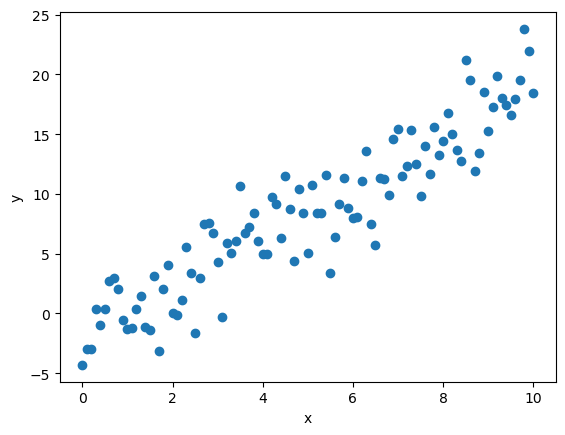

In [50]:
fig, ax = plt.subplots()
ax.scatter(X, Y, label='data')
plt.xlabel('x')
plt.ylabel('y')

In [53]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.1)

In [56]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [57]:
print(X_train)

[[1.196e+01 1.090e+00 2.300e+00 ... 9.900e-01 3.130e+00 8.860e+02]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.229e+01 2.830e+00 2.220e+00 ... 1.150e+00 3.300e+00 2.900e+02]
 ...
 [1.284e+01 2.960e+00 2.610e+00 ... 8.900e-01 2.150e+00 5.900e+02]
 [1.421e+01 4.040e+00 2.440e+00 ... 8.700e-01 3.330e+00 1.080e+03]
 [1.221e+01 1.190e+00 1.750e+00 ... 1.280e+00 3.070e+00 7.180e+02]]


In [58]:
Xtrain = Xtrain.reshape(-1, 1)

In [59]:
print(Xtrain)

[[ 2.5]
 [ 4.1]
 [ 0.9]
 [ 2.9]
 [ 9.4]
 [ 8.6]
 [ 1.7]
 [ 1.9]
 [ 0.3]
 [ 6.5]
 [ 3.8]
 [ 8.2]
 [ 1.2]
 [ 6.4]
 [ 7.7]
 [ 2.4]
 [ 1. ]
 [ 2.7]
 [ 6.2]
 [ 8. ]
 [ 7.5]
 [ 4.4]
 [ 5.6]
 [ 7.2]
 [ 7.3]
 [ 0. ]
 [ 7.1]
 [ 9. ]
 [ 5. ]
 [ 2. ]
 [ 7.9]
 [ 6.7]
 [ 9.6]
 [ 5.3]
 [ 7. ]
 [10. ]
 [ 0.8]
 [ 6.9]
 [ 1.4]
 [ 9.9]
 [ 3.3]
 [ 7.6]
 [ 9.3]
 [ 7.8]
 [ 8.7]
 [ 4.9]
 [ 8.1]
 [ 6.1]
 [ 5.9]
 [ 4. ]
 [ 6.8]
 [ 2.6]
 [ 1.3]
 [ 5.2]
 [ 9.8]
 [ 8.3]
 [ 0.2]
 [ 9.1]
 [ 3.2]
 [ 0.4]
 [ 9.5]
 [ 0.6]
 [ 5.4]
 [ 4.5]
 [ 2.1]
 [ 5.7]
 [ 9.2]
 [ 3.9]
 [ 4.7]
 [ 5.1]
 [ 6.3]
 [ 0.5]
 [ 3.1]
 [ 0.1]
 [ 3.6]
 [ 7.4]
 [ 8.4]
 [ 5.8]
 [ 1.6]
 [ 1.1]
 [ 6.6]
 [ 4.2]
 [ 2.3]
 [ 4.6]
 [ 3.7]
 [ 0.7]
 [ 2.2]
 [ 3. ]
 [ 8.8]
 [ 5.5]]


In [63]:

reg.fit(Xtrain, ytrain)

LinearRegression()

In [66]:
reg.coef_


array([2.06359919])

In [67]:
reg.intercept_

-2.108830663662509

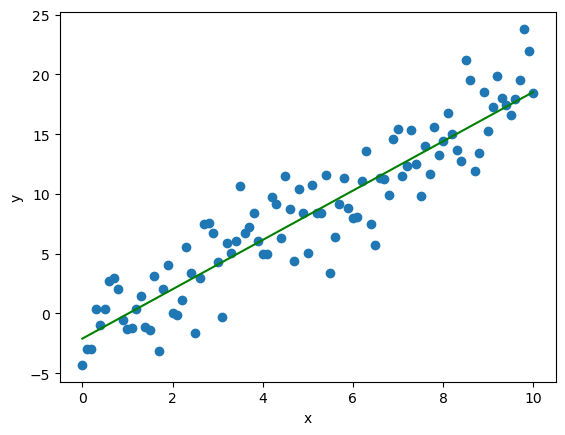

In [69]:
x = np.array([0, 10])
ax.plot(x, reg.coef_[0]*x + reg.intercept_, 'g', label ='fitted model')
fig